In [ ]:
import os
os.environ["PYMBAR_SOLVER"] = "scipy"  # Disable JAX JIT overhead for fast PyMBAR solving
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import sys, os, re, glob
from math import ceil
import numpy as np
import pandas as pd
import seaborn as sb
from scipy.spatial.transform import Rotation as R
from scipy import stats
import mdtraj as md
import tables as tb
import nglview as nv
# %matplotlib inline
import matplotlib as mpl
from ipywidgets import Play, IntSlider, HBox, VBox, Label, ToggleButtons, link
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.matlab.hist as hist

upside_home = os.environ["UPSIDE_HOME"]
upside_utils_dir = os.path.join(upside_home, "py3", "py") if os.path.exists(os.path.join(upside_home, "py3", "py")) else os.path.join(upside_home, "py")
if upside_utils_dir not in sys.path:
    sys.path.append(upside_utils_dir)
import mdtraj_upside as mu

base_dir = os.path.join(os.getcwd(), os.pardir, "simulations", "upside", "nug2b") + "/"
up_indir = base_dir + "inputs/hdx/"
pdb_id = "nug2b"
n_rep = 20

output_dir = base_dir + "outputs/"

init_fn = up_indir + "{}.initial.npy".format(pdb_id)
fasta_fn = up_indir + "{}.fasta".format(pdb_id)
chain_breaks_fn = up_indir + "{}.chain_breaks".format(pdb_id)
if not os.path.exists(chain_breaks_fn):
    chain_breaks_fn = ""

# Each .run.N.up is a fixed-temperature REMD *slot*, not one walker: replica_index
# changes on ~87% of consecutive frames, so neighbouring frames are unrelated
# structures. load_upside_rep demultiplexes to follow a single replica.
run_fns = sorted(glob.glob(output_dir + "remd/{}.run.[0-9]*.up".format(pdb_id)),
                 key=lambda f: int(re.search(r"run\.(\d+)\.up$", f).group(1)))
rep_select = 0
traj = mu.load_upside_rep(run_fns, rep_select)

# Remove global tumbling/translation so the animation shows conformational change.
ca_idx = traj.top.select("name CA")
traj.superpose(traj, 0, atom_indices=ca_idx)

acid_sele = traj.top.select("(resname ASP or resname GLU) and name CA")
base_sele = traj.top.select("(resname LYS or resname ARG) and name CA")
print(traj)

Very Important: All distances are in nanometers for MDTraj
<mdtraj.Trajectory with 1978 frames, 362 atoms, 61 residues, without unitcells>


In [2]:
# DSSP calculation & Secondary Structure colors
dssp = md.compute_dssp(traj, simplified=True)
dssp_colors = {"H": "#ff2255", "E": "#0099ff", "C": "#aaaaaa"}

view = nv.NGLWidget()
view.add_trajectory(traj, default_representation=False)
view.camera = "orthographic"
view.parameters = {"clipNear": -100, "clipFar": 1000, "fogNear": 0, "fogFar": 1000}

# Close nglview built-in player GUI to eliminate double play box
view._iplayer.close()

mode_toggle = ToggleButtons(
    options=["Acid/Base", "DSSP Secondary Structure"],
    description="View Mode:",
    button_style="",
)

def update_representation(frame_idx=0):
    view.clear_representations()
    if mode_toggle.value == "Acid/Base":
        view.add_cartoon(color="#888888")
        view.add_spacefill(selection=acid_sele, color="#ff0000")
        view.add_spacefill(selection=base_sele, color="#0000ff")
    else:
        current_dssp = dssp[frame_idx]
        for ss_code, color in dssp_colors.items():
            res_seqs = [str(traj.top.residue(i).resSeq) for i, ss in enumerate(current_dssp) if ss == ss_code]
            if res_seqs:
                view.add_cartoon(selection=" or ".join(res_seqs), color=color)

n_frames = traj.n_frames
view.max_frame = n_frames - 1

player = Play(value=0, min=0, max=n_frames - 1, step=1, interval=100)
slider = IntSlider(value=0, min=0, max=n_frames - 1, continuous_update=True, readout=False, layout={"width": "400px"})
readout = Label(value="frame 0 / {}".format(n_frames - 1))

link((player, "value"), (slider, "value"))
link((slider, "value"), (view, "frame"))

def on_frame_change(change):
    frame = change["new"]
    readout.value = "frame {} / {}".format(frame, n_frames - 1)
    if mode_toggle.value == "DSSP Secondary Structure":
        update_representation(frame)

slider.observe(on_frame_change, names="value")
mode_toggle.observe(lambda c: update_representation(slider.value), names="value")

# Initial rendering
update_representation(0)

VBox([mode_toggle, view, HBox([player, slider, readout])])


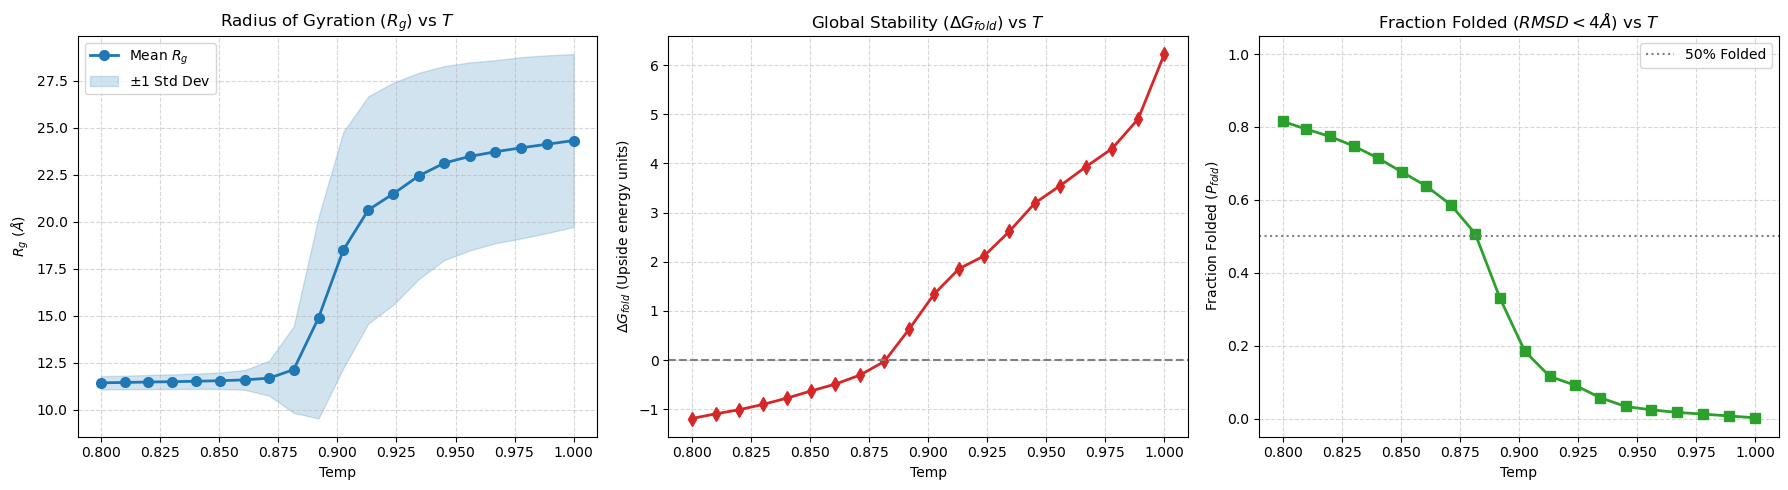

In [ ]:
# Fast Raw Bin Analysis using direct HDF5 / NumPy loading

# 1. REMD 20-replica ensemble
run_fns_20rep = sorted(glob.glob(output_dir + "remd_20rep/{}.run.[0-9]*.up".format(pdb_id)),
                       key=lambda f: int(re.search(r"run\.(\d+)\.up$", f).group(1)))

ref_traj = mu.load_upside_ref(run_fns_20rep[0], add_atoms=False)
ca_idx = ref_traj.top.select("name CA")

temps_20rep = []
for fn in run_fns_20rep:
    with tb.open_file(fn) as t:
        temps_20rep.append(float(t.root.output.temperature[0,0]))
temps_20rep = np.array(temps_20rep)

# 2. REMD Low-temperature ensemble
run_fns_lowtemp = sorted(glob.glob(output_dir + "remd_lowtemp/{}.run.[0-9]*.up".format(pdb_id)),
                         key=lambda f: int(re.search(r"run\.(\d+)\.up$", f).group(1)))

temps_lowtemp = []
for fn in run_fns_lowtemp:
    with tb.open_file(fn) as t:
        temps_lowtemp.append(float(t.root.output.temperature[0,0]))
temps_lowtemp = np.array(temps_lowtemp)

print(f"Loaded {len(temps_20rep)} 20rep replicas and {len(temps_lowtemp)} lowtemp replicas.")



In [ ]:
import os
os.environ["PYMBAR_SOLVER"] = "scipy"  # Ensure scipy solver before pymbar import
# MBAR Reweighting for HDX and Global Stability following Peng et al. (scripts/04.HDX/4.calc_HDX.py)
import os
from pymbar import MBAR
import time

t0 = time.time()
print("Computing MBAR-reweighted thermodynamics across REMD replicas (Peng et al. 04.HDX protocol)...")

pdb_id = 'nug2b'
output_dir = '../simulations/upside/nug2b/outputs/'
result_dir = '../docs/data/upside_hdx/'
start_frame = 100

run_fns = sorted(glob.glob(output_dir + 'remd_lowtemp/{}.run.[0-9]*.up'.format(pdb_id)),
                 key=lambda f: int(re.search(r'run\.(\d+)\.up$', f).group(1)))

n_rep = len(run_fns)

Pot = []
T = []
PS = []

for i, fn in enumerate(run_fns):
    with tb.open_file(fn) as t:
        temp = float(t.root.output.temperature[0,0])
        pot = np.array(t.root.output.potential[:]).flatten()
    ps_fn = f'{result_dir}/{pdb_id}_remd_lowtemp_stride1_{i}_PS.npy'
    ps = np.load(ps_fn)
    n = min(len(pot), ps.shape[0])
    Pot.append(pot[:n])
    T.append(temp)
    PS.append(ps[:n])

min_f = min(len(p) for p in Pot)
Pot = np.array([p[:min_f] for p in Pot])
T = np.array(T)
PS = np.array([p[:min_f] for p in PS])

res = np.loadtxt(f'{result_dir}/{pdb_id}_stride1.resid', dtype=int)
n_res = min(res.size, PS.shape[2])

# --- 1. MBAR Initialization (04.HDX using fast scipy hybr solver) ---
kB = 1.0
beta = kB * T**(-1)
cE0 = Pot[:, start_frame:]

FN = cE0[0].size
FNs = np.zeros([n_rep], np.int32) + FN
reducedPot0 = np.zeros([n_rep, n_rep, FN], np.float32)
for k in range(n_rep):
    for l in range(n_rep):
        reducedPot0[k, l] = beta[l] * cE0[k]

mbar0 = MBAR(reducedPot0, FNs, solver_protocol=[{'method': 'hybr'}], verbose=False)

# --- 2. Calculate dG_HX at target temperature (04.HDX) ---
T_target = 0.80   # Target reduced temperature
m_sens   = 0.04   # Denaturant sensitivity for urea

pf_frame = np.sum(PS[:, start_frame:, :n_res], axis=2).flatten()
den = np.linspace(0.0, 15.0, 151)
TT = (T_target / 0.85) * 298.0
m_eff = -m_sens * pf_frame

u_n = (cE0 / (T_target * kB)).flatten()
try:
    log_w1 = mbar0._computeUnnormalizedLogWeights(u_n)
except AttributeError:
    log_w1 = mbar0._compute_log_weights(u_n)

w1 = np.exp(log_w1 - np.max(log_w1))
w1 /= np.sum(w1)

dGhx_D = []
for d in den:
    w = np.exp(m_eff * d / T_target) * w1
    w /= np.sum(w)
    
    probp = np.zeros(n_res)
    for j in range(n_res):
        pf_i = PS[:, start_frame:, j].flatten()
        probp[j] = np.sum(pf_i * w)
    probp_clipped = np.clip(probp, 1e-4, 1.0 - 1e-4)
    dGhx_D.append(TT * np.log(probp_clipped / (1.0 - probp_clipped)) * 0.001987)

dGhx_D = np.array(dGhx_D)

t_calc = time.time() - t0

# --- 3. Plotting (04.HDX format) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residue-level dG_HX at [den]=0
axes[0].bar(res[:n_res], dGhx_D[0, :n_res], color='#1f77b4', alpha=0.85)
axes[0].set_xlabel('Residue Number')
axes[0].set_ylabel(r'$\Delta G_{HX}$ (kcal/mol)')
axes[0].set_title(r'Residue-Level $\Delta G_{HX}$ at {target}=0.80$')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: dG_HX vs [denaturant] for selected residues
for i in range(0, n_res, 5):
    axes[1].plot(den, dGhx_D[:, i], label=f'Res {res[i]}')
axes[1].set_xlabel('[Denaturant] (M)')
axes[1].set_ylabel(r'$\Delta G_{HX}$ (kcal/mol)')
axes[1].set_title(r'$\Delta G_{HX}$ vs Denaturant Concentration')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

